In [1]:
#importing the libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [43]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
!pip3 install -U ucimlrepo

In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_prognostic = fetch_ucirepo(id=16)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_prognostic.data.features
y = breast_cancer_wisconsin_prognostic.data.targets

# metadata
print(breast_cancer_wisconsin_prognostic.metadata)

# variable information
print(breast_cancer_wisconsin_prognostic.variables)


{'uci_id': 16, 'name': 'Breast Cancer Wisconsin (Prognostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/16/breast+cancer+wisconsin+prognostic', 'data_url': 'https://archive.ics.uci.edu/static/public/16/data.csv', 'abstract': 'Prognostic Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 198, 'num_features': 33, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Outcome'], 'index_col': ['ID'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1995, 'last_updated': 'Sun Jan 14 2024', 'dataset_doi': '10.24432/C5GK50', 'creators': ['William Wolberg', 'W. Street', 'Olvi Mangasarian'], 'intro_paper': None, 'additional_info': {'summary': 'Each record represents follow-up data for one breast cancer case.  These are consecutive patients seen by Dr. Wolberg since 1984, and include only those cases exhibiting invasive brea

In [6]:
X.head(20)

,Time,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,tumor_size,lymph_node_status
0,31,18.02,27.60,117.50,1013.0,0.09489,0.10360,0.10860,0.07055,0.1865,...,139.70,1436.0,0.1195,0.1926,0.3140,0.11700,0.2677,0.08113,5.0,5.0
1,61,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,3.0,2.0
2,116,21.37,17.44,137.50,1373.0,0.08836,0.11890,0.12550,0.08180,0.2333,...,159.10,1949.0,0.1188,0.3449,0.3414,0.20320,0.4334,0.09067,2.5,0.0
3,123,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,2.0,0.0
4,27,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,3.5,0.0
5,77,12.75,15.29,84.60,502.7,0.11890,0.15690,0.16640,0.07666,0.1995,...,107.30,733.2,0.1706,0.4196,0.5999,0.17090,0.3485,0.11790,2.5,0.0
6,60,18.98,19.61,124.40,1112.0,0.09087,0.12370,0.12130,0.08910,0.1727,...,152.60,1593.0,0.1144,0.3371,0.2990,0.19220,0.2726,0.09581,1.5,NaN
7,77,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,4.0,10.0
8,119,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,2.0,1.0
9,76,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,6.0,20.0


In [7]:
y.head(10)

,Outcome
0,N
1,N
2,N
3,N
4,R
5,R
6,N
7,R
8,N
9,N


In [8]:
X.shape

(198, 33)

In [9]:
missing_data=X.isnull().sum()
print(missing_data)

Time                  0
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
tumor_size            0
lymph_node_status     4
dtype: int64


In [10]:
data_with_missing = X[X.isnull().any(axis=1)]
X.dropna(inplace=True)

In [11]:
missing_data=y.isnull().sum()
print(missing_data)

Outcome    0
dtype: int64


In [31]:
# Ensure y is a DataFrame before concatenation
if not isinstance(y, pd.DataFrame):
    y = pd.DataFrame(y)

# Combine X and y into a single DataFrame to handle missing values consistently
data = pd.concat([X, y], axis=1)

# Drop rows with missing values
data.dropna(inplace=True)

# Separate X and y again
X = data.drop(y.columns, axis=1)
y = data[y.columns]

In [12]:
X.describe()

,Time,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,tumor_size,lymph_node_status
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,...,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,46.938144,17.402320,22.300979,114.781495,969.092268,0.102774,0.142642,0.156309,0.086808,0.192885,...,140.136907,1401.756701,0.143921,0.364567,0.436010,0.178449,0.322251,0.090777,2.867526,3.211340
std,34.523646,3.171672,4.335292,21.430694,353.159959,0.012607,0.050229,0.070942,0.033962,0.027679,...,28.826843,587.040705,0.022092,0.165528,0.174757,0.045529,0.074068,0.021371,1.950588,5.479276
min,1.000000,10.950000,10.380000,71.900000,361.600000,0.074970,0.046050,0.023980,0.020310,0.130800,...,85.100000,508.100000,0.081910,0.051310,0.023980,0.028990,0.156500,0.055040,0.400000,0.000000
25%,14.250000,15.052500,19.342500,98.160000,702.525000,0.093900,0.109850,0.106075,0.063760,0.174075,...,117.925000,940.575000,0.129325,0.247550,0.322150,0.152225,0.275950,0.076368,1.500000,0.000000
50%,39.500000,17.290000,21.795000,113.700000,929.100000,0.102200,0.131750,0.152050,0.086075,0.189350,...,136.500000,1295.000000,0.141750,0.350450,0.401150,0.178500,0.310300,0.086540,2.500000,1.000000
75%,73.000000,19.580000,24.782500,129.650000,1193.500000,0.111375,0.172200,0.200500,0.103925,0.209550,...,159.875000,1694.250000,0.154450,0.423675,0.550175,0.207125,0.358475,0.101775,3.500000,4.000000
max,125.000000,27.220000,39.280000,182.100000,2250.000000,0.144700,0.311400,0.426800,0.201200,0.304000,...,232.200000,3903.000000,0.222600,1.058000,1.170000,0.290300,0.663800,0.207500,10.000000,27.000000


In [13]:
y.describe()

,Outcome
count,198
unique,2
top,N
freq,151


In [14]:
X.columns

Index(['Time', 'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3', 'tumor_size', 'lymph_node_status'],
      dtype='object')

In [15]:
# X = X.drop(columns=['Time'])


In [16]:
display(X.head())

,Time,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,tumor_size,lymph_node_status
0,31,18.02,27.60,117.50,1013.0,0.09489,0.1036,0.1086,0.07055,0.1865,...,139.70,1436.0,0.1195,0.1926,0.3140,0.1170,0.2677,0.08113,5.0,5.0
1,61,17.99,10.38,122.80,1001.0,0.11840,0.2776,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,3.0,2.0
2,116,21.37,17.44,137.50,1373.0,0.08836,0.1189,0.1255,0.08180,0.2333,...,159.10,1949.0,0.1188,0.3449,0.3414,0.2032,0.4334,0.09067,2.5,0.0
3,123,11.42,20.38,77.58,386.1,0.14250,0.2839,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,2.0,0.0
4,27,20.29,14.34,135.10,1297.0,0.10030,0.1328,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,3.5,0.0


In [17]:
y.columns

Index(['Outcome'], dtype='object')

In [18]:
#Encode Categorical Variables
le = LabelEncoder()
for col in y.columns:
    y[col] = le.fit_transform(y[col])

y.head()

,Outcome
0,0
1,0
2,0
3,0
4,1


In [29]:
# Data scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Time,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,tumor_size,lymph_node_status
0,-0.462853,0.195253,1.225461,0.127179,0.124650,-0.627033,-0.779281,-0.674251,-0.479935,-0.231263,...,-0.015195,0.058483,-1.108262,-1.041587,-0.699976,-1.353154,-0.738394,-0.452563,1.096075,0.327286
1,0.408365,0.185770,-2.756867,0.375128,0.090583,1.242682,2.693812,2.032129,1.779861,1.775458,...,1.546411,1.054169,0.829555,1.823322,1.582786,1.914715,1.865927,1.319332,0.068091,-0.221649
2,2.005598,1.254211,-1.124159,1.062835,1.146655,-1.146354,-0.473888,-0.435411,-0.147829,1.463945,...,0.659530,0.934619,-1.140030,-0.119123,-0.542781,0.545029,1.504517,-0.005015,-0.188905,-0.587605
3,2.208882,-1.891052,-0.444249,-1.740389,-1.655059,3.159319,2.819562,1.202549,0.542951,2.420217,...,-1.435248,-1.424458,2.989745,3.038939,1.439360,1.740751,4.623205,3.857313,-0.445902,-0.587605
4,-0.579016,0.912816,-1.841070,0.950556,0.930899,-0.196784,-0.196440,0.589198,0.516382,-0.434109,...,0.419550,0.295876,-0.295922,-0.966482,-0.206592,-0.351213,-1.162070,-0.656634,0.325087,-0.587605


<Axes: xlabel='Outcome', ylabel='count'>

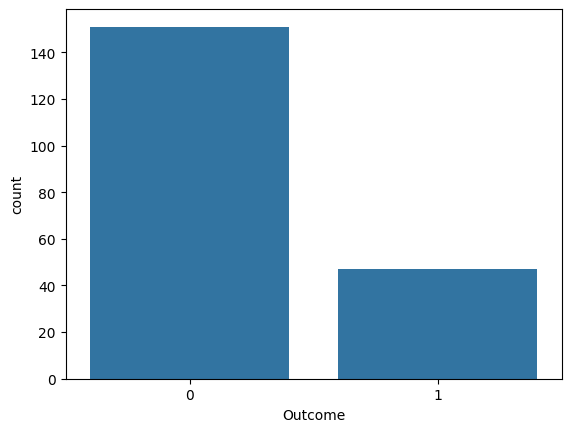

In [19]:
sns.countplot(x=y['Outcome'])

<Axes: xlabel='Outcome', ylabel='area3'>

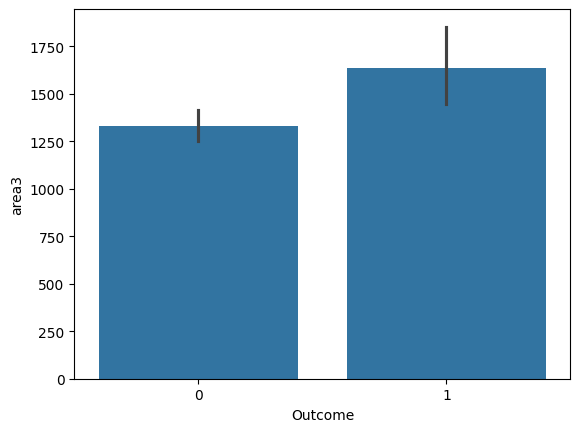

In [20]:
sns.barplot(x=y['Outcome'], y=X['area3'])

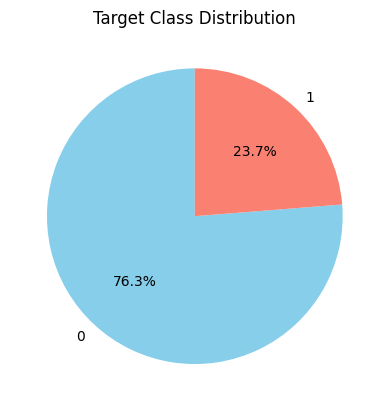

In [21]:
class_counts = y['Outcome'].value_counts()

class_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Target Class Distribution')
plt.ylabel('')
plt.show()

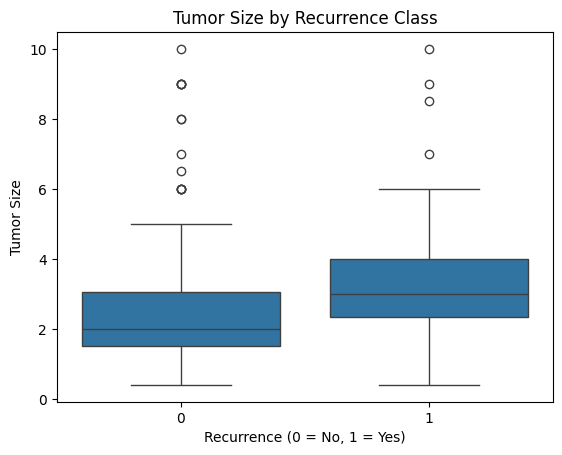

In [22]:
sns.boxplot(x=y['Outcome'], y=X['tumor_size'])
plt.title('Tumor Size by Recurrence Class')
plt.xlabel('Recurrence (0 = No, 1 = Yes)')
plt.ylabel('Tumor Size')
plt.show()

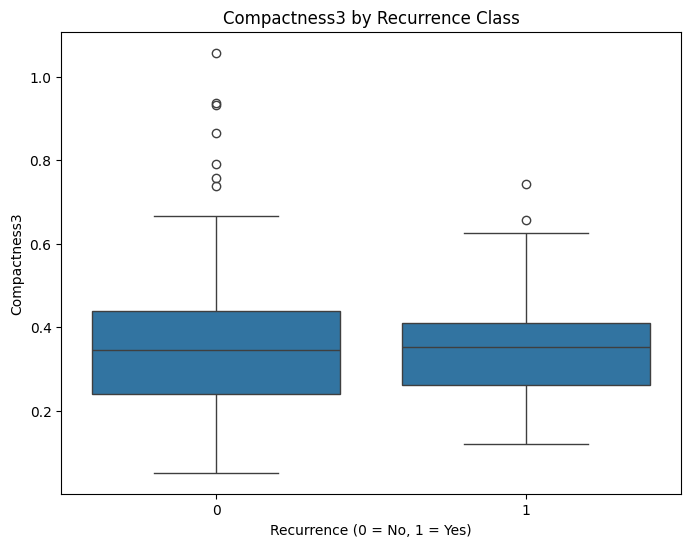

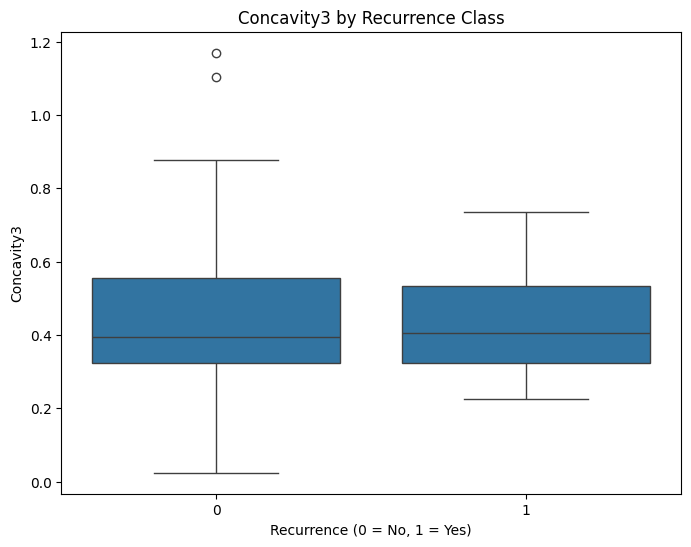

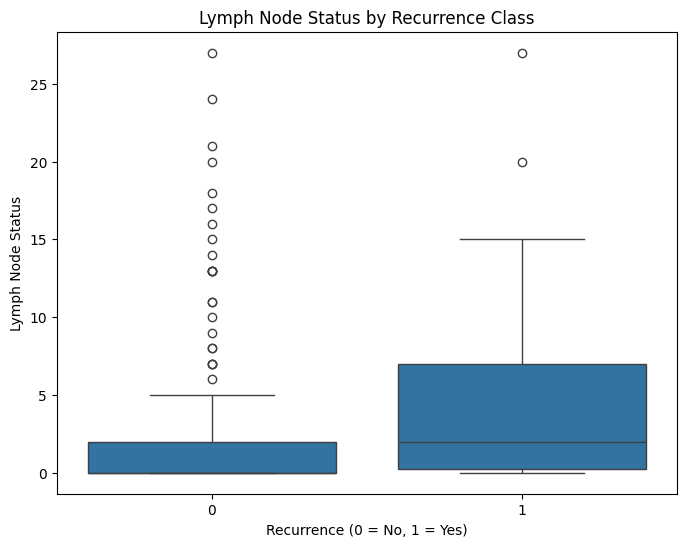

In [23]:
#box plot for 'compactness3' and 'Outcome'
plt.figure(figsize=(8, 6))
sns.boxplot(x=y['Outcome'], y=X['compactness3'])
plt.title('Compactness3 by Recurrence Class')
plt.xlabel('Recurrence (0 = No, 1 = Yes)')
plt.ylabel('Compactness3')
plt.show()

#box plot for 'concavity3' and 'Outcome'
plt.figure(figsize=(8, 6))
sns.boxplot(x=y['Outcome'], y=X['concavity3'])
plt.title('Concavity3 by Recurrence Class')
plt.xlabel('Recurrence (0 = No, 1 = Yes)')
plt.ylabel('Concavity3')
plt.show()

#box plot for 'lymph_node_status' and 'Outcome'
plt.figure(figsize=(8, 6))
sns.boxplot(x=y['Outcome'], y=X['lymph_node_status'])
plt.title('Lymph Node Status by Recurrence Class')
plt.xlabel('Recurrence (0 = No, 1 = Yes)')
plt.ylabel('Lymph Node Status')
plt.show()

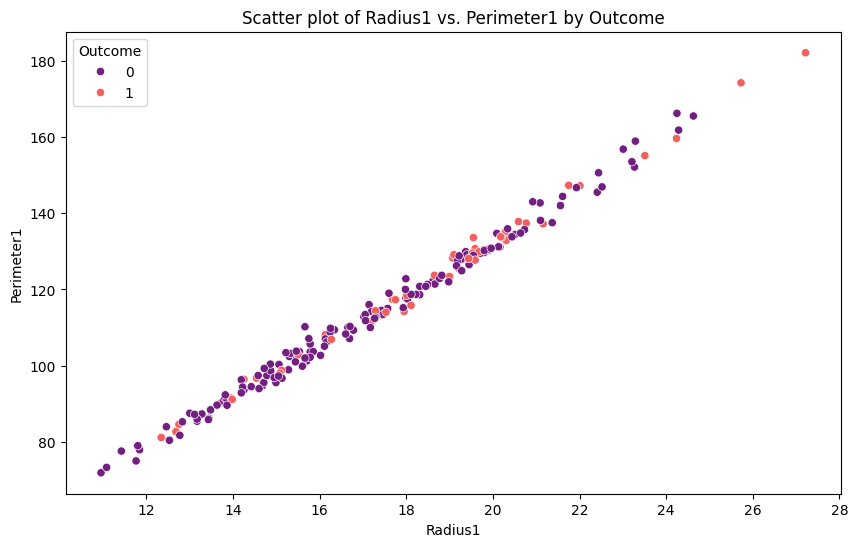

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['radius1'], y=X['perimeter1'], hue=y['Outcome'], palette='magma', hue_order=[0, 1])
plt.title('Scatter plot of Radius1 vs. Perimeter1 by Outcome')
plt.xlabel('Radius1')
plt.ylabel('Perimeter1')
# plt.legend(title='Outcome', labels=['No Recurrence', 'Recurrence']) # Removed manual legend call
plt.show()

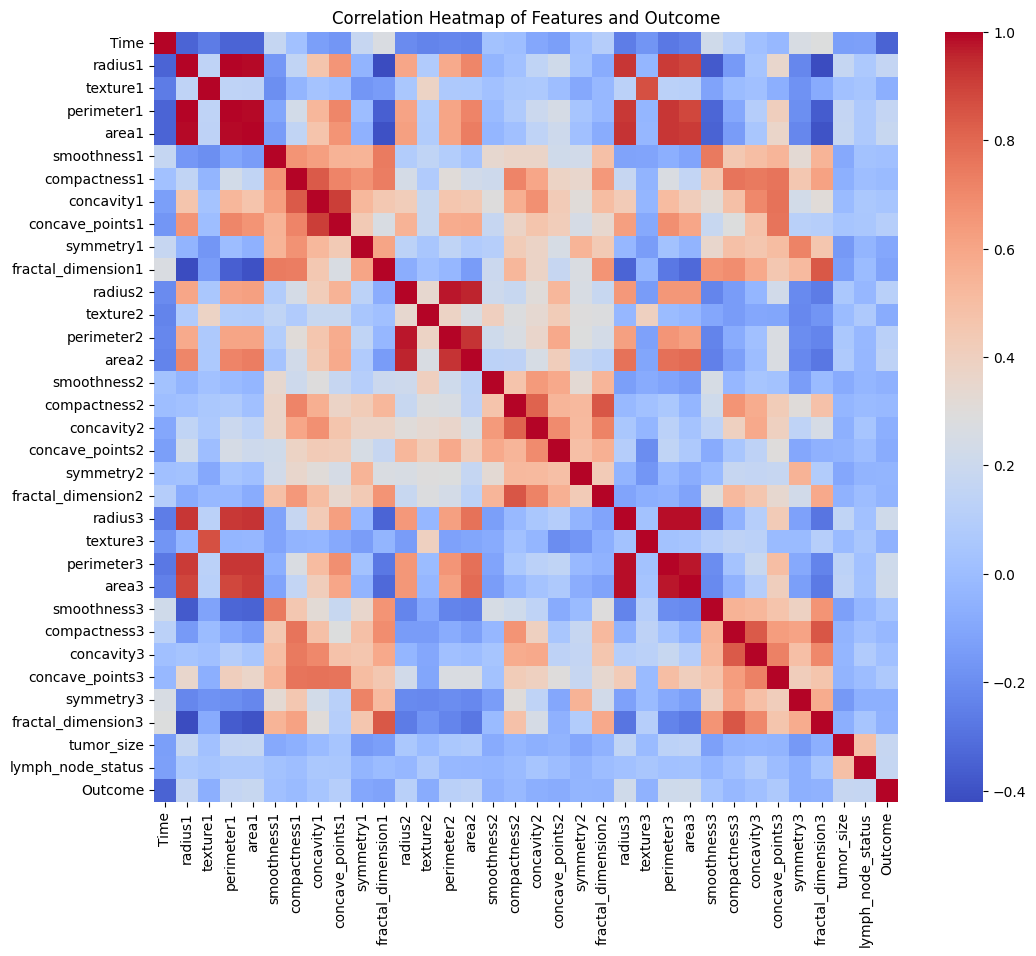

In [25]:
# Concatenate X and y to include the target variable in the correlation analysis
data = pd.concat([X, y], axis=1)

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Generate a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Features and Outcome')
plt.show()

In [32]:
# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Encoded classes:', le.classes_)

# Print shapes before splitting
print('Shape of X_scaled before split:', X_scaled.shape)
print('Shape of y_encoded before split:', y_encoded.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
print('Training set size:', X_train.shape)
print('Test set size (X_test, y_test):', X_test.shape, y_test.shape)

Encoded classes: [0 1]
Shape of X_scaled before split: (194, 33)
Shape of y_encoded before split: (194,)
Training set size: (155, 33)
Test set size (X_test, y_test): (39, 33) (39,)


In [39]:
# Train Logistic Regression model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('Logistic Regression Accuracy:',round(accuracy_score(y_test, y_pred_lr)*100, 2), '%')
print('\nClassification Report (Logistic Regression):\n', classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 89.74 %

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        32
           1       0.71      0.71      0.71         7

    accuracy                           0.90        39
   macro avg       0.83      0.83      0.83        39
weighted avg       0.90      0.90      0.90        39



In [40]:
# Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest Accuracy:', round(accuracy_score(y_test, y_pred_rf)*100, 2), '%')
print('\nClassification Report (Random Forest):\n', classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 92.31 %

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.91      1.00      0.96        32
           1       1.00      0.57      0.73         7

    accuracy                           0.92        39
   macro avg       0.96      0.79      0.84        39
weighted avg       0.93      0.92      0.91        39



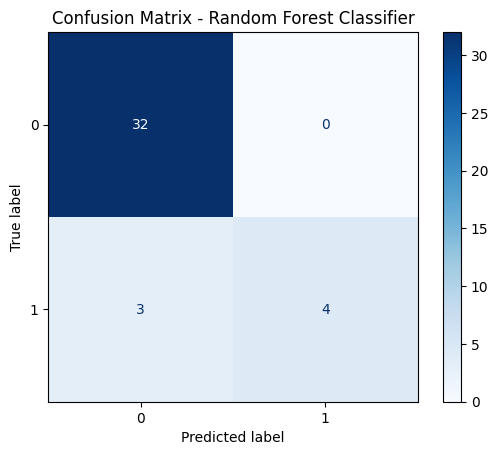

In [44]:
# Confusion matrix heatmap for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

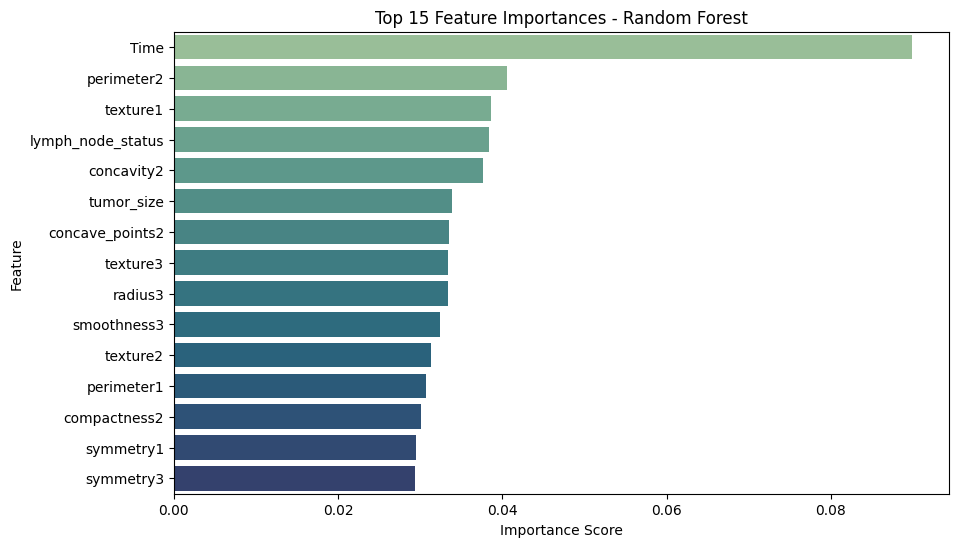

In [45]:
# Feature importance visualization
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances[:15], y=importances.index[:15], palette='crest')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [47]:
#Testing the model using logistic regression
predicted_recurrence = lr.predict([[30,19.02,27.77,118.64,1013.24,0.14250,0.2414,0.0880, 0.2597,0.09744,0.5678,2.7685,0.09876,1.3456,6.7892,1.095,24.45,119.26,1117.77,0.16250,0.57687,0.11880,0.3654,21.67,38.08,159.10,1436.0,0.3449,0.4000,0.6638,0.17300,6.6,0.0]])
print("Predicted Recurrence:", predicted_recurrence)



Predicted Recurrence: [0]


In [48]:
#Testing the model using logistic regression
predicted_recurrence = rf.predict([[30,19.02,27.77,118.64,1013.24,0.14250,0.2414,0.0880, 0.2597,0.09744,0.5678,2.7685,0.09876,1.3456,6.7892,1.095,24.45,119.26,1117.77,0.16250,0.57687,0.11880,0.3654,21.67,38.08,159.10,1436.0,0.3449,0.4000,0.6638,0.17300,6.6,0.0]])
print("Predicted Recurrence:", predicted_recurrence)



Predicted Recurrence: [0]
